# Lowpass Gate (Vactrol / Buchla 292)

| Function | Description |
| --- | --- |
| `lowpass_gate` | Buchla 292c/292e lowpass gate emulation. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.virtual_analog import lowpass_gate

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Buchla 292c/292e lowpass gate: vactrol response and mode comparison.

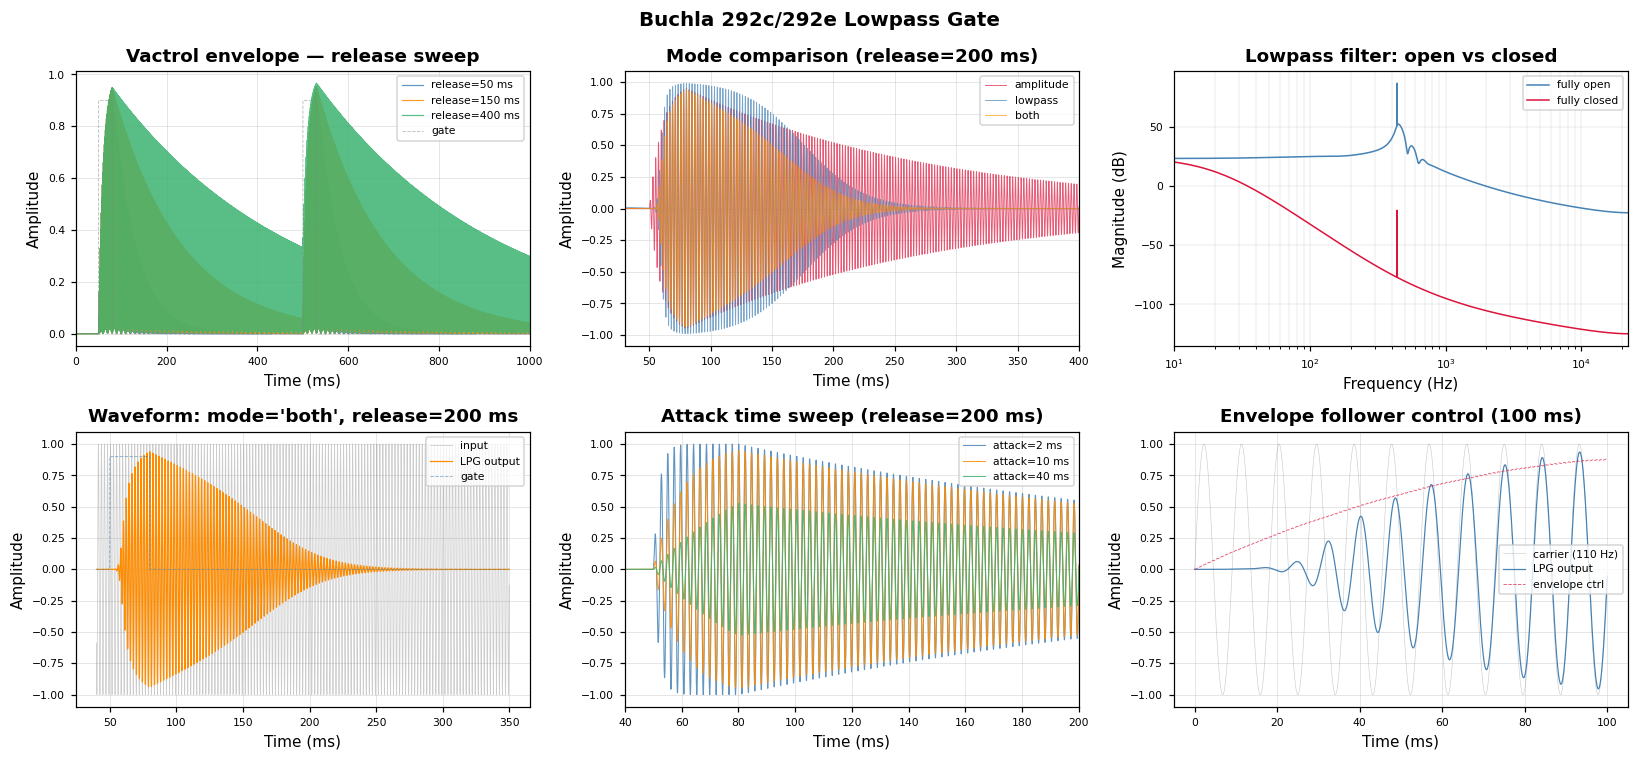

In [2]:
FS = 44100
DURATION = 1.0
N = int(FS * DURATION)
t_ms = np.arange(N) / FS * 1000

_, sig = generate_sine(freq=440.0, fs=FS, duration=DURATION)

# Gate: short pulse at t=50ms, second pulse at t=500ms
ctrl = np.zeros(N)
ctrl[int(0.05 * FS): int(0.08 * FS)] = 1.0
ctrl[int(0.50 * FS): int(0.53 * FS)] = 1.0

RELEASE_TIMES = [0.05, 0.15, 0.40]
COLORS = ["steelblue", "darkorange", "mediumseagreen"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# Vactrol brightness for different release times
ax = axes[0, 0]
for rt, color in zip(RELEASE_TIMES, COLORS):
    out = lowpass_gate(sig, ctrl, fs=FS, mode="amplitude",
                       attack_time=0.010, release_time=rt)
    rms_env = np.abs(out)  # proxy for brightness envelope
    ax.plot(t_ms, rms_env, color=color, linewidth=0.8, alpha=0.85,
            label=f"release={rt*1000:.0f} ms")
ax.plot(t_ms, ctrl * 0.9, color="gray", linewidth=0.6, linestyle="--", alpha=0.5, label="gate")
ax.set_title("Vactrol envelope — release sweep", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, 1000)
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Mode comparison: amplitude vs lowpass vs both
MODES = ["amplitude", "lowpass", "both"]
MODE_COLORS = ["crimson", "steelblue", "darkorange"]
ax = axes[0, 1]
for mode, color in zip(MODES, MODE_COLORS):
    out = lowpass_gate(sig, ctrl, fs=FS, mode=mode,
                       attack_time=0.010, release_time=0.200)
    ax.plot(t_ms, out, color=color, linewidth=0.6, alpha=0.7, label=mode)
ax.set_title("Mode comparison (release=200 ms)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_xlim(30, 400)
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Frequency content comparison: open vs closed
ax = axes[0, 2]
ctrl_open = np.ones(N)
ctrl_closed = np.zeros(N)
out_open = lowpass_gate(sig, ctrl_open, fs=FS, mode="lowpass")
out_closed = lowpass_gate(sig, ctrl_closed, fs=FS, mode="lowpass")
freqs = np.fft.rfftfreq(N, d=1.0 / FS)
db_open = 20 * np.log10(np.abs(np.fft.rfft(out_open)) + 1e-12)
db_closed = 20 * np.log10(np.abs(np.fft.rfft(out_closed)) + 1e-12)
mask = freqs > 5
ax.semilogx(freqs[mask], db_open[mask], color="steelblue", linewidth=1.0, label="fully open")
ax.semilogx(freqs[mask], db_closed[mask], color="crimson", linewidth=1.0, label="fully closed")
ax.set_title("Lowpass filter: open vs closed", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(10, FS / 2)
ax.legend(fontsize=7)
ax.grid(True, which="both", linewidth=0.3, alpha=0.5)

# Waveform zoom: single pulse, both mode
out_both = lowpass_gate(sig, ctrl, fs=FS, mode="both",
                        attack_time=0.010, release_time=0.200)
ax = axes[1, 0]
zoom = slice(int(0.04 * FS), int(0.35 * FS))
ax.plot(t_ms[zoom], sig[zoom], color="gray", linewidth=0.5, alpha=0.4, label="input")
ax.plot(t_ms[zoom], out_both[zoom], color="darkorange", linewidth=0.8, label="LPG output")
ax.plot(t_ms[zoom], ctrl[zoom] * 0.9, color="steelblue", linewidth=0.6,
        linestyle="--", alpha=0.6, label="gate")
ax.set_title("Waveform: mode='both', release=200 ms", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Attack time sweep
ATTACK_TIMES = [0.002, 0.010, 0.040]
ax = axes[1, 1]
for at, color in zip(ATTACK_TIMES, COLORS):
    out = lowpass_gate(sig, ctrl, fs=FS, mode="amplitude",
                       attack_time=at, release_time=0.200)
    ax.plot(t_ms, out, color=color, linewidth=0.7, alpha=0.85,
            label=f"attack={at*1000:.0f} ms")
ax.set_title("Attack time sweep (release=200 ms)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_xlim(40, 200)
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Envelope-following: control from rectified audio
_, carrier = generate_sine(freq=110.0, fs=FS, duration=DURATION)
_, modulator = generate_sine(freq=3.0, fs=FS, duration=DURATION)
modulated = sig * (0.5 + 0.5 * modulator)  # AM signal
# Smooth rectified modulated signal as envelope follower
from scipy.signal import lfilter
alpha_env = 1.0 - np.exp(-1.0 / (0.030 * FS))
env_ctrl = lfilter([alpha_env], [1.0, -(1.0 - alpha_env)], np.abs(modulated))
env_ctrl = np.clip(env_ctrl / (np.max(env_ctrl) + 1e-12), 0.0, 1.0)
out_follow = lowpass_gate(carrier, env_ctrl, fs=FS, mode="both",
                          attack_time=0.005, release_time=0.050)
ax = axes[1, 2]
ax.plot(t_ms[:4410], carrier[:4410], color="gray", linewidth=0.4, alpha=0.4, label="carrier (110 Hz)")
ax.plot(t_ms[:4410], out_follow[:4410], color="steelblue", linewidth=0.8, label="LPG output")
ax.plot(t_ms[:4410], env_ctrl[:4410] * 0.9, color="crimson", linewidth=0.6,
        linestyle="--", alpha=0.7, label="envelope ctrl")
ax.set_title("Envelope follower control (100 ms)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)

fig.suptitle("Buchla 292c/292e Lowpass Gate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()